<a href="https://colab.research.google.com/github/Jef-H/supervised_fields/blob/develop/Supervised_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Supervised Field Detection - Jef Hinton

Alright so for this supervised learning module we're going to train the model to classify drawings as field or non-field

Two datasets for this project the main dataset is from kaggle https://www.kaggle.com/datasets/mahmoudreda55/satellite-image-classification/data


The field dataset was created via taking 125 screenshots of corn fields by hand from https://earthexplorer.usgs.gov/ and then fragmenting them into images comparable to the forest size sampling we have in the kaggle dataset.

All the fun of that process is depicted below.

---





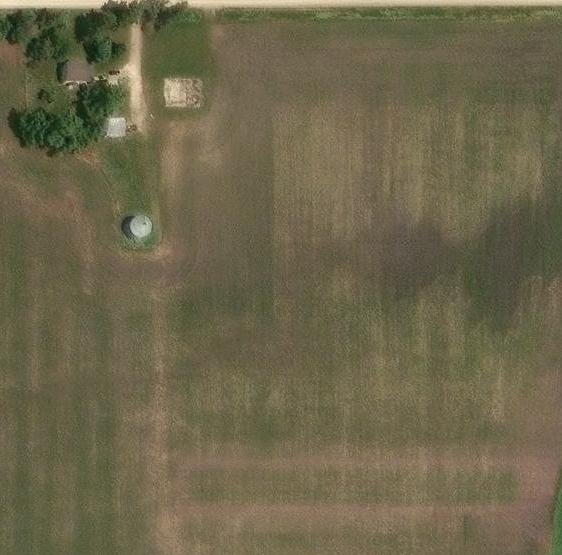


# Assemble Field Data



*   go to https://earthexplorer.usgs.gov/
*   find Iowa
*   zoom in all the way, and start taking screenshots of corn fields.
*   upload the images to github
*   write some code to fragment the images



In [20]:
import seaborn as sns
import matplotlib.pyplot as plt
import os
from PIL import Image
import pandas as pd
import zipfile
import requests
import time
import tempfile
import shutil


In [21]:
def download_png_files_from_github(github_url, output_dir):
    """
    Downloads all PNG files from a specified GitHub repository directory,
    clearing the destination directory before downloading.

    Args:
        github_url (str): The GitHub URL of the repository directory.
        output_dir (str): Directory to save the downloaded PNG files.
    """
    # Ensure the output directory exists and clean it
    if os.path.exists(output_dir):
        shutil.rmtree(output_dir)  # Remove all files in the directory
    os.makedirs(output_dir, exist_ok=True)
    print(f"Cleaned and prepared output directory: {output_dir}")

    # Extract the repository name and directory from the GitHub URL
    repo_url = github_url.split("https://github.com/")[1]
    repo_name, tree_path = repo_url.split("/tree/")

    # Correctly format the path for the API (removing 'tree' and using branch name)
    branch_name = tree_path.split('/')[0]  # Assuming branch name is the first part of the path
    dir_path = '/'.join(tree_path.split('/')[1:])  # Directory path is the rest

    # GitHub API URL to list the contents of the directory
    api_url = f"https://api.github.com/repos/{repo_name}/contents/{dir_path}?ref={branch_name}"

    # Send a request to the GitHub API
    response = requests.get(api_url)
    if response.status_code != 200:
        print(f"Failed to fetch contents from {api_url}. Status code: {response.status_code}")
        return

    files = response.json()
    png_count = 0  # Counter for PNG files

    # Iterate through each file in the directory
    for file in files:
        # Check if the file is a PNG
        if file['name'].endswith('.png'):
            file_url = file['download_url']
            file_name = file['name']
            file_path = os.path.join(output_dir, file_name)

            # Download and save the PNG file
            file_response = requests.get(file_url)
            if file_response.status_code == 200:
                with open(file_path, 'wb') as f:
                    f.write(file_response.content)
                png_count += 1  # Increment the PNG counter
            else:
                print(f"Failed to download {file_name}")

    print(f"Downloaded {png_count} PNG files to {output_dir}")

# Example usage
github_url = "https://github.com/Jef-H/supervised_fields/tree/develop/crop_field_images"
output_directory = "downloaded_png_files/"

download_png_files_from_github(github_url, output_directory)


Cleaned and prepared output directory: downloaded_png_files/
Downloaded 125 PNG files to downloaded_png_files/


In [22]:
def cut_images_to_fragments(input_dir, output_dir, fragment_size=(64, 64)):
    """
    Cuts all PNG images in the input directory into fragments of the given size
    and saves them to the output directory. Excess parts of the images are discarded.

    Args:
        input_dir (str): Directory containing PNG images.
        output_dir (str): Directory to save the image fragments.
        fragment_size (tuple): Size of each fragment (width, height).
    """
    start_time = time.time()  # Start the timer

    # Clear the output directory before writing new fragments
    if os.path.exists(output_dir):
        shutil.rmtree(output_dir)  # Remove the existing directory and its contents
    os.makedirs(output_dir, exist_ok=True)  # Create a fresh directory
    print(f"Ensured output directory is cleared and exists: {output_dir}")

    total_fragment_count = 0  # Counter for all fragments across all images

    # Iterate through each file in the input directory
    for filename in os.listdir(input_dir):
        if filename.endswith('.png'):
            file_path = os.path.join(input_dir, filename)
            with Image.open(file_path) as img:
                img_width, img_height = img.size

                # Calculate the number of fragments in each dimension
                num_fragments_x = img_width // fragment_size[0]
                num_fragments_y = img_height // fragment_size[1]

                total_fragments = 0

                # Generate and save each fragment
                for i in range(num_fragments_x):
                    for j in range(num_fragments_y):
                        left = i * fragment_size[0]
                        upper = j * fragment_size[1]
                        right = left + fragment_size[0]
                        lower = upper + fragment_size[1]

                        fragment = img.crop((left, upper, right, lower))

                        fragment_filename = f"{os.path.splitext(filename)[0]}_{i}_{j}.png"
                        fragment_path = os.path.join(output_dir, fragment_filename)
                        fragment.save(fragment_path)

                        total_fragments += 1
                        total_fragment_count += 1

    print(f"Total fragments created for all images: {total_fragment_count}")

    # End the timer and print the elapsed time
    elapsed_time = time.time() - start_time
    print(f"Processing completed in {elapsed_time:.2f} seconds.")

# Example usage
github_url = "https://github.com/Jef-H/supervised_fields/tree/develop/crop_field_images"
output_directory = "crop_fragments/"

# Create temporary directory outside the 'with' context to avoid deletion
temp_dir = tempfile.mkdtemp()
print(f"Temporary directory created: {temp_dir}")
input_directory = "downloaded_png_files/"

cut_images_to_fragments(input_directory, output_directory)


Temporary directory created: /tmp/tmp5yzyui_t
Ensured output directory is cleared and exists: crop_fragments/
Total fragments created for all images: 5343
Processing completed in 12.16 seconds.


# Assemble Non-Field Data



*   go to kaggle & download zip
*   upload to github so we didn't have to mess with api keys.



In [23]:
# URL of the ZIP file on GitHub
zip_url = 'https://github.com/Jef-H/supervised_fields/blob/develop/Sat_img_class.zip?raw=true'

# Define the directory to save the extracted files
extract_dir = 'satellite_images'

# Step 1: Download the ZIP file
response = requests.get(zip_url)
zip_file_path = 'Sat_img_class.zip'

# Save the file
with open(zip_file_path, 'wb') as f:
    f.write(response.content)

# Step 2: Extract the ZIP file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(f'ZIP file extracted to {extract_dir}')

# Step 3: Optional - Display the extracted files
extracted_files = os.listdir(extract_dir)
print(f'Files extracted: {extracted_files}')

# You can also process the images, e.g., using PIL or other libraries


ZIP file extracted to satellite_images
Files extracted: ['data']


# Get the shape of the data

An image data set has less fun charts to make, but I can show you some of the data we're working with.

In [24]:
# Define the list of base directories
base_dirs = [
    "satellite_images/data/desert",
    "satellite_images/data/green_area",
    "satellite_images/data/water",
    "satellite_images/data/cloudy",
    "crop_fragments/"
]

# Initialize a list to store statistics
stats = []

def get_image_stats(base_dirs):
    # Iterate through each directory in base_dirs
    for base_dir in base_dirs:
        # Iterate through the directory and its subdirectories
        for dirpath, dirnames, filenames in os.walk(base_dir):
            # Initialize counters and accumulators for dimensions
            total_images = 0
            total_width = 0
            total_height = 0

            # Loop through each file in the directory
            for filename in filenames:
                # Check if the file is an image (you can add other formats if needed)
                if filename.lower().endswith(('.jpg', '.png', '.jpeg')):
                    total_images += 1
                    try:
                        # Open the image and get its dimensions
                        with Image.open(os.path.join(dirpath, filename)) as img:
                            width, height = img.size
                            total_width += width
                            total_height += height
                    except Exception as e:
                        print(f"Error processing {filename}: {e}")

            # Calculate average dimensions if there are images
            if total_images > 0:
                avg_width = total_width / total_images
                avg_height = total_height / total_images
            else:
                avg_width = avg_height = 0

            # Append the stats for the current directory
            stats.append({
                'Directory': dirpath,
                'Total Images': total_images,
                'Average Width': avg_width,
                'Average Height': avg_height
            })

    # Convert the stats to a pandas DataFrame for better formatting
    stats_df = pd.DataFrame(stats)

    # Print the summary
    print(stats_df)

# Call the function to calculate and print stats
get_image_stats(base_dirs)

                          Directory  Total Images  Average Width  \
0      satellite_images/data/desert          1131          256.0   
1  satellite_images/data/green_area          1500           64.0   
2       satellite_images/data/water          1500           64.0   
3      satellite_images/data/cloudy          1500          256.0   
4                   crop_fragments/          5343           64.0   

   Average Height  
0           256.0  
1            64.0  
2            64.0  
3           256.0  
4            64.0  


Alright so green area and water are generally 64x64 but desert and cloudy are 256x256

I build the crop fragments data set pretty large, and should probably clean that up before we start training so the model just isn't biased based on the sheer number of crop fragmetns it sees.

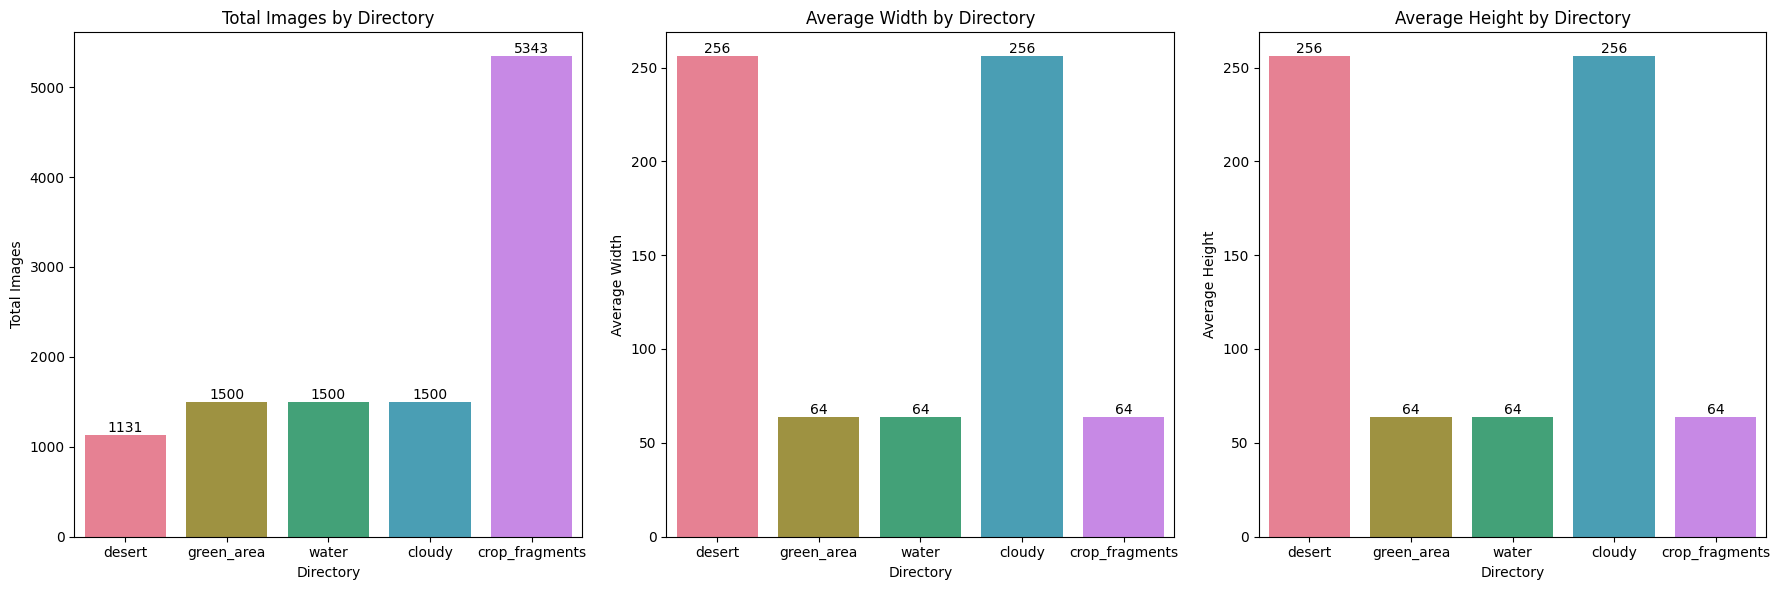

In [25]:
# Data
data = {
    "Directory": [
        "desert",
        "green_area",
        "water",
        "cloudy",
        "crop_fragments"
    ],
    "Total Images": [1131, 1500, 1500, 1500, 5343],
    "Average Width": [256.0, 64.0, 64.0, 256.0, 64.0],
    "Average Height": [256.0, 64.0, 64.0, 256.0, 64.0],
}

df = pd.DataFrame(data)


# Create a 1x3 grid of bar charts
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False)

# Helper function to add labels on the bars
def add_labels(ax):
    for bar in ax.patches:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{int(bar.get_height())}",
            ha="center",
            va="bottom",
            fontsize=10,
        )

# Bar plot for Total Images
sns.barplot(
    x="Directory",
    y="Total Images",
    data=df,
    palette="husl",
    ax=axes[0],
    hue="Directory",
    legend=False
)
axes[0].set_title("Total Images by Directory")
axes[0].set_xticks(range(len(axes[0].get_xticks())))
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
add_labels(axes[0])

# Bar plot for Average Width
sns.barplot(
    x="Directory",
    y="Average Width",
    data=df,
    palette="husl",
    ax=axes[1],
    hue="Directory",
    legend=False
)
axes[1].set_title("Average Width by Directory")
axes[1].set_xticks(range(len(axes[1].get_xticks())))
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
add_labels(axes[1])

# Bar plot for Average Height
sns.barplot(
    x="Directory",
    y="Average Height",
    data=df,
    palette="husl",
    ax=axes[2],
    hue="Directory",
    legend=False
)
axes[2].set_title("Average Height by Directory")
axes[2].set_xticks(range(len(axes[2].get_xticks())))
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=0)
add_labels(axes[2])

# Adjust layout to avoid overlap
plt.tight_layout()
plt.show()

examples of the images

Crop field

# 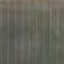

Cloudy

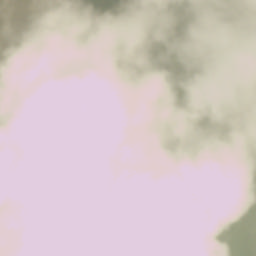

Desert

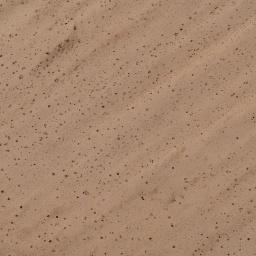

Green area

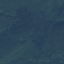

water

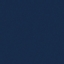





### Known potential issues

so the field dataset was acquired through taking screen shots of fields in iowa. I'm unsure what resolution the satellite imagry I was using was and I'm unsure what the resolution of the base data set was. an interesting side quest could be seeing what impacts image resolution, and image size has on the model. I'm planning on using 64x64 to start, and if the results are bad, there are pleanty of more corn fields I can take screenshots of.

If the model isn't performing well I may consider cropping, flipping, or rotating images in training to help it generalize better.